In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [4]:
X = df.drop("target", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [6]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

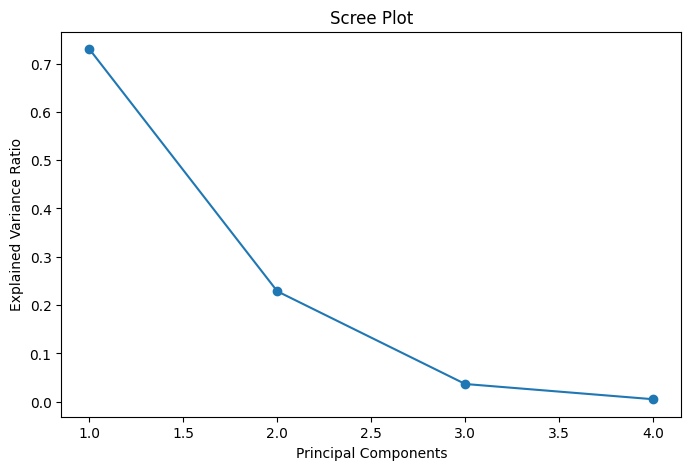

In [7]:
plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o')

plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.show()

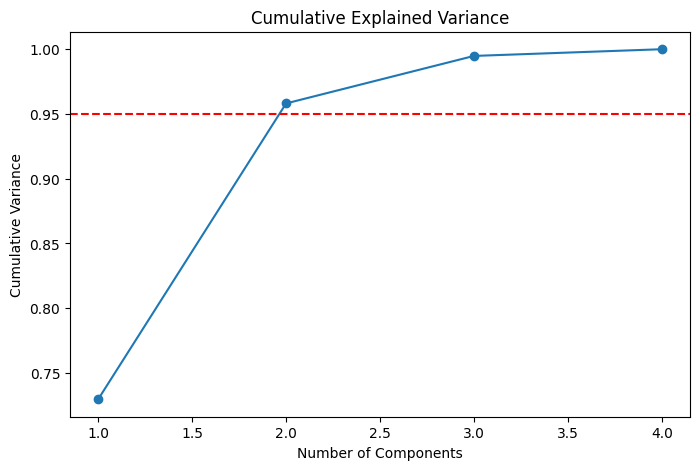

In [8]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))

plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='o')

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")

plt.axhline(y=0.95, color='r', linestyle='--')

plt.show()

In [9]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_2d, columns=["PC1", "PC2"])
pca_df["target"] = df["target"]

pca_df.head()

,PC1,PC2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


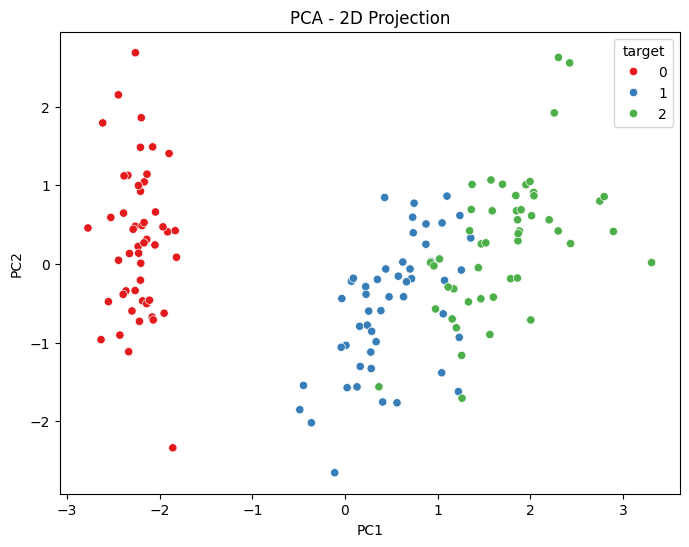

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="target",
    palette="Set1"
)

plt.title("PCA - 2D Projection")
plt.show()

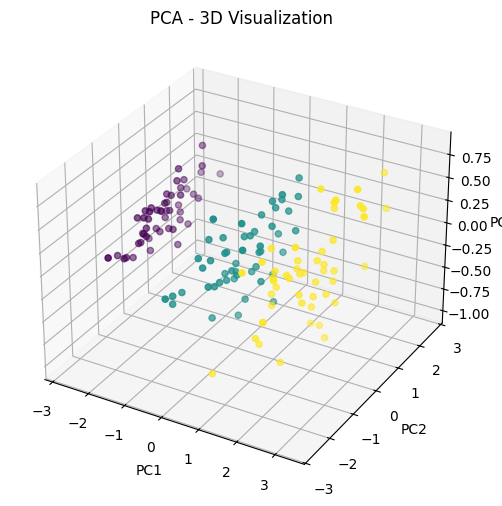

In [11]:
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_3d[:,0],
    X_3d[:,1],
    X_3d[:,2],
    c=df["target"]
)

ax.set_title("PCA - 3D Visualization")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

In [12]:
for i, v in enumerate(explained_variance):
    print(f"PC{i+1}: {v:.4f}")

PC1: 0.7296
PC2: 0.2285
PC3: 0.0367
PC4: 0.0052


In [13]:
optimal_components = np.argmax(cumulative_variance >= 0.95) + 1
optimal_components

np.int64(2)

In [14]:
print("Original shape:", X_scaled.shape)
print("Reduced shape (2D):", X_2d.shape)

Original shape: (150, 4)
Reduced shape (2D): (150, 2)
